# IPCC AR6 SPM.7(a) — extraction and cleaning

Extracts a tidy table of mitigation options (potentials and costs, 2030) from the SYR Figure SPM.7(a) source file.

- **Source:** [doi:10.48490/3c86-xp02](https://doi.org/10.48490/3c86-xp02) (raw file in this folder)
- **Review:** `../../README.md` · **Need:** `2026-06-action-reduction-potential`
- Each cleaning block implements one parsing note from the review README.

In [1]:
import pandas as pd

RAW = "data/6119_AR6 SYR Data for Figure SPM7(a) Mitigation Options.xlsx"
OUT = "data/spm7a_mitigation_options_2030_clean.csv"
COST_COLS = ["cost_lt0", "cost_0_20", "cost_20_50", "cost_50_100", "cost_100_200", "cost_unallocated"]

## 1. Load raw

The `Final` sheet matches the published SYR figure. No transformations here — this is what the publisher ships.

In [2]:
raw = pd.read_excel(RAW, sheet_name="Final", header=0, engine="openpyxl")
df = raw.rename(columns=dict(zip(raw.columns[:11],
    ["label"] + COST_COLS[:5] + ["cost_unallocated", "total", "unc_low", "unc_high", "smooth"])))
df = df[["label"] + COST_COLS + ["total", "unc_low", "unc_high", "smooth"]]
print(f"raw shape: {raw.shape} -> kept {df.shape[1]} named columns")

raw shape: (43, 11) -> kept 11 named columns


## 2. Clean

One block per parsing note.

In [3]:
# Rows below the "MERGING:" marker are working notes (geothermal/hydro split)
# that double-count options — truncate there.
cut = df.index[df.label.astype(str).str.strip().str.startswith("MERGING")][0]
df = df.loc[:cut - 1]
print(f"truncated at row {cut}; {len(df)} rows remain")

truncated at row 39; 39 rows remain


In [4]:
# The sheet is padded to 1000 phantom rows (Numbers export artifact) — drop empties.
df = df.dropna(subset=["label"])
print(f"{len(df)} non-empty rows")

35 non-empty rows


In [5]:
# Sector headers (ENERGY, LAND/WATER/FOOD, ...) are inline all-caps rows,
# not a column — promote them to a 'sector' column.
is_header = df.label.str.strip().str.isupper()
df["sector"] = df.label.where(is_header).ffill().str.strip().str.title()
df = df[~is_header]
print(f"{len(df)} option rows across {df.sector.nunique()} sectors")

31 option rows across 4 sectors


In [6]:
# Name hygiene: trailing whitespace, and one label truncated in the SYR export —
# full name taken from the file's own 'WGIII data' sheet.
df["option"] = df.label.str.strip()
df.loc[df.option == "Carbon capture with", "option"] = "Carbon capture with utilization and storage"
print("names cleaned; longest:", df.option.str.len().max(), "chars")

names cleaned; longest: 51 chars


In [7]:
# Numeric coercion (stray ' ' strings in cost cells) and the 'smooth' flag
# (smooth = cost-bucket breakdown is an even-spread estimate, not measured).
for c in COST_COLS + ["total", "unc_low", "unc_high"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["smooth"] = df.smooth.eq("smooth")

tidy = df[["sector", "option"] + COST_COLS + ["total", "unc_low", "unc_high", "smooth"]].reset_index(drop=True)
tidy.head(8)

,sector,option,cost_lt0,cost_0_20,cost_20_50,cost_50_100,cost_100_200,cost_unallocated,total,unc_low,unc_high,smooth
0,Energy,Solar,2.700,0.600,0.600,0.600,NaN,NaN,4.50,2.00,7.00,True
1,Energy,Wind,2.310,0.770,0.770,NaN,NaN,NaN,3.85,2.10,5.60,True
2,Energy,"Reduce CH4 from coal, oil and gas",0.350,1.020,0.100,0.080,0.100,NaN,1.65,NaN,NaN,False
3,Energy,Bioelectricity (includes BECCS),NaN,NaN,NaN,0.580,0.580,NaN,1.16,NaN,NaN,False
4,Energy,Geothermal and hydropower,NaN,0.350,0.350,0.350,NaN,NaN,1.06,NaN,NaN,False
5,Energy,Nuclear,0.176,0.176,0.176,0.176,0.176,NaN,0.88,0.44,1.32,True
6,Energy,Fossil Carbon Capture and Storage (CCS),NaN,NaN,NaN,0.270,0.270,NaN,0.54,0.27,0.81,True
7,"Land, Water, Food",Reduce conversion of natural ecosystems,NaN,2.280,0.120,1.630,NaN,NaN,4.03,2.53,7.35,False


## 3. Validate

Assertions against published facts — if any fail, the cleaning is wrong; do not export.

In [8]:
# Expected option count and unique, clean names
assert len(tidy) == 31, f"expected 31 options, got {len(tidy)}"
assert tidy.option.is_unique
assert not tidy.option.str.match(r"^\s|\s$").any()

# Spot-check totals against the published figure (GtCO2e/yr, 2030)
for opt, val in {"Solar": 4.5, "Wind": 3.85, "Electric vehicles": 0.8,
                 "Reduce conversion of natural ecosystems": 4.03}.items():
    got = tidy.loc[tidy.option == opt, "total"].iloc[0]
    assert abs(got - val) < 1e-9, (opt, got)

# Cost buckets should sum to the total. Two options carry small rounding
# residues in the source itself (<= 0.02 GtCO2e) — known, accepted.
KNOWN_ROUNDING = {"Geothermal and hydropower", "Forest and fire management"}
resid = (tidy[COST_COLS].sum(axis=1) - tidy.total).abs()
bad = tidy[(resid > 0.01) & ~tidy.option.isin(KNOWN_ROUNDING)]
assert bad.empty, bad.option.tolist()
assert resid[tidy.option.isin(KNOWN_ROUNDING)].max() <= 0.025

print("all validations passed")
print(f"uncertainty bounds present for {tidy.unc_low.notna().sum()}/31 options")

all validations passed
uncertainty bounds present for 21/31 options


## 4. Export

In [9]:
tidy.to_csv(OUT, index=False)
print(f"wrote {OUT}: {tidy.shape[0]} rows x {tidy.shape[1]} cols")

wrote data/spm7a_mitigation_options_2030_clean.csv: 31 rows x 12 cols


## 5. Fit analysis

Three questions from the need (`2026-06-action-reduction-potential`): what does the ordinal ranking look like, which ranks are real vs effective ties, and how sensitive is the ranking to using cost buckets.

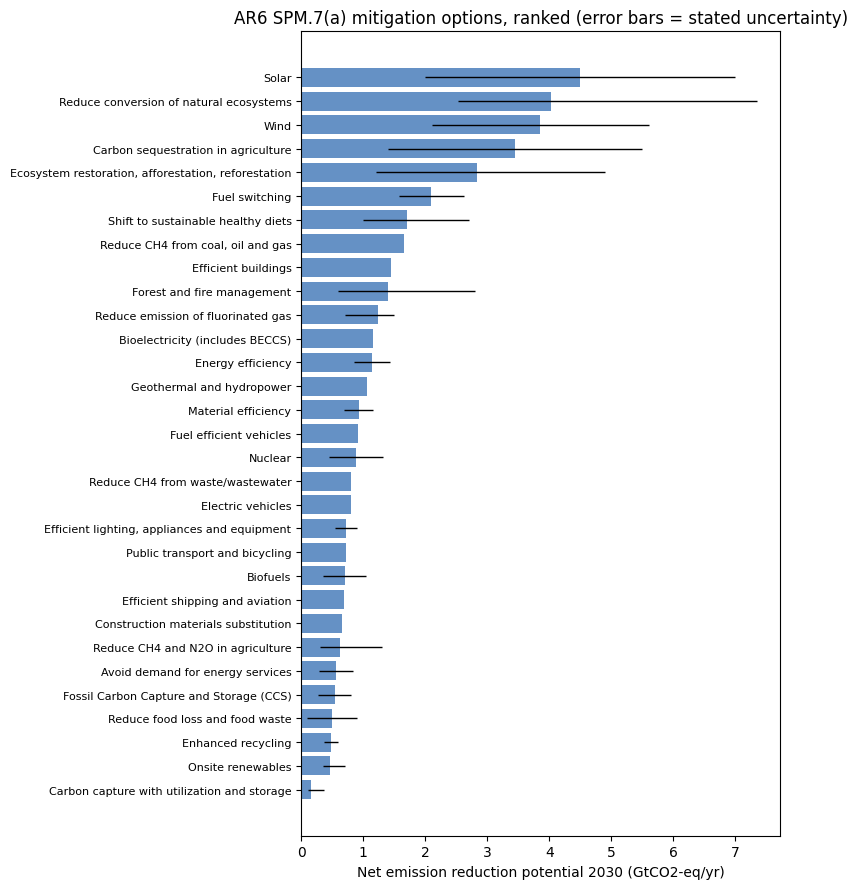

In [10]:
# 5.1 Ordinal ranking by total potential
import matplotlib.pyplot as plt

rk = tidy.sort_values("total", ascending=False).reset_index(drop=True)
rk["rank"] = rk.index + 1

fig, ax = plt.subplots(figsize=(8, 9))
y = range(len(rk))
err_lo = (rk.total - rk.unc_low).fillna(0)
err_hi = (rk.unc_high - rk.total).fillna(0)
ax.barh(y, rk.total, xerr=[err_lo, err_hi], color="#4a7ebb", alpha=0.85, error_kw=dict(lw=1))
ax.set_yticks(y); ax.set_yticklabels(rk.option, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Net emission reduction potential 2030 (GtCO2-eq/yr)")
ax.set_title("AR6 SPM.7(a) mitigation options, ranked (error bars = stated uncertainty)")
plt.tight_layout(); plt.show()

In [11]:
# 5.2 Effective ties — how many other options' uncertainty intervals overlap each option's?
# Stated bounds where present; otherwise the caption's worst-case "typically 25-50%"
# is applied as +/-50% (assumption, flagged - 10 options lack stated bounds).
lo = rk.unc_low.fillna(rk.total * 0.5)
hi = rk.unc_high.fillna(rk.total * 1.5)
rk["overlaps"] = [((lo <= hi[i]) & (hi >= lo[i])).sum() - 1 for i in rk.index]
print("Options ranked 1-5 overlap with 7-18 others; ranking is robust only at coarse tiers.")
rk[["rank", "option", "total", "unc_low", "unc_high", "overlaps"]].head(12)

Options ranked 1-5 overlap with 7-18 others; ranking is robust only at coarse tiers.


,rank,option,total,unc_low,unc_high,overlaps
0,1,Solar,4.500,2.00000,7.00000,9
1,2,Reduce conversion of natural ecosystems,4.030,2.53000,7.35000,7
2,3,Wind,3.850,2.10000,5.60000,9
3,4,Carbon sequestration in agriculture,3.440,1.40000,5.50000,13
4,5,"Ecosystem restoration, afforestation, reforest...",2.840,1.20000,4.90000,18
5,6,Fuel switching,2.099,1.57425,2.62375,11
6,7,Shift to sustainable healthy diets,1.700,1.00000,2.70000,22
7,8,"Reduce CH4 from coal, oil and gas",1.650,NaN,NaN,25
8,9,Efficient buildings,1.440,NaN,NaN,26
9,10,Forest and fire management,1.400,0.60000,2.80000,29


In [12]:
# 5.3 Cost-bucket sensitivity — ranking by potential available below a cost threshold.
# Options with all potential in "no costs allocable" VANISH under any cost-based ranking.
rk["pot_le20"] = rk[["cost_lt0", "cost_0_20"]].sum(axis=1)
rk["pot_le100"] = rk[["cost_lt0", "cost_0_20", "cost_20_50", "cost_50_100"]].sum(axis=1)
rk["rank_le20"] = rk.pot_le20.rank(ascending=False, method="min").astype(int)
rk["rank_le100"] = rk.pot_le100.rank(ascending=False, method="min").astype(int)

vanish = rk[(rk.pot_le100 == 0) & (rk.total > 0)].option.tolist()
print("Vanish under cost-bucket ranking (all potential unallocated to cost):")
for v in vanish: print(" -", v)

biggest_moves = (rk.assign(shift=(rk.rank_le100 - rk["rank"]).abs())
                   .sort_values("shift", ascending=False))
biggest_moves[["option", "rank", "rank_le20", "rank_le100"]].head(8)

Vanish under cost-bucket ranking (all potential unallocated to cost):
 - Shift to sustainable healthy diets
 - Electric vehicles
 - Reduce food loss and food waste
 - Carbon capture with utilization and storage


,option,rank,rank_le20,rank_le100
6,Shift to sustainable healthy diets,7,22,28
8,Efficient buildings,9,19,23
11,Bioelectricity (includes BECCS),12,22,21
18,Electric vehicles,19,22,28
20,Public transport and bicycling,21,9,15
19,"Efficient lighting, appliances and equipment",20,8,14
28,Enhanced recycling,29,22,24
24,Reduce CH4 and N2O in agriculture,25,16,20


In [13]:
# 5.4 How many potential bands can the data support?
# Strict test: the longest chain of options each clearly above the next
# (uncertainty ranges not overlapping) caps the number of distinct levels.
import numpy as np
lo2, hi2 = rk.unc_low.fillna(rk.total*0.5), rk.unc_high.fillna(rk.total*1.5)
n = len(rk)
best = [1]*n
for i in range(n):
    for j in range(i):
        if lo2[j] > hi2[i]: best[i] = max(best[i], best[j]+1)
print(f"max statistically distinct levels: {max(best)} -> 3 bands, not 5")

# Natural 3-band breaks = two largest gaps in log(total)
s = rk.sort_values("total", ascending=False).reset_index(drop=True)
gaps = np.diff(-np.log(s.total.values))
cuts = np.sort(np.argsort(gaps)[-2:])
s["band"] = "medium"
s.loc[:cuts[0], "band"] = "high"
s.loc[cuts[1]+1:, "band"] = "low"
print(s.groupby("band").total.agg(["count", "min", "max"]))
print("high:", s[s.band=="high"].option.tolist())
print("low :", s[s.band=="low"].option.tolist())

# Quintile check: 5 bands would put 26/31 options' uncertainty across a band edge
edges = s.total.quantile([.2, .4, .6, .8]).values
crosses = ((lo2.values[:,None] < edges) & (hi2.values[:,None] > edges)).any(axis=1).sum()
print(f"under 5 quintile bands, {crosses}/31 options straddle a band edge — fake precision")

max statistically distinct levels: 3 -> 3 bands, not 5
        count    min    max
band                       
high        5  2.840  4.500
low         1  0.152  0.152
medium     25  0.470  2.099
high: ['Solar', 'Reduce conversion of natural ecosystems', 'Wind', 'Carbon sequestration in agriculture', 'Ecosystem restoration, afforestation, reforestation']
low : ['Carbon capture with utilization and storage']
under 5 quintile bands, 26/31 options straddle a band edge — fake precision


In [14]:
# 5.5 Band composition of the TEF mapping
mp = pd.read_csv("data/spm7a_option_to_tef.csv")
mp = mp[mp.stable_id.notna() & (mp.stable_id != "")]
mp = mp.merge(s[["option", "band"]], left_on="action_name", right_on="option")
print("options mapped per band:", mp.groupby("band").option.nunique().to_dict())
print("distinct TEs per band  :", mp.groupby("band").stable_id.nunique().to_dict())
dup = mp.groupby("stable_id").band.nunique()
print("TEs spanning two bands :", dup[dup > 1].index.tolist())

options mapped per band: {'high': 2, 'medium': 17}
distinct TEs per band  : {'high': 4, 'medium': 107}
TEs spanning two bands : ['solar_rooftops']


## Findings

**Extraction**
- 31 options across 4 sectors extract cleanly; all spot-checks against published figure values pass.
- Two source-side rounding residues (≤0.02 GtCO2e): Geothermal and hydropower, Forest and fire management — accepted, asserted as known (also noted in review README).
- Uncertainty bounds present for 21/31 options; `smooth=True` options (7) have even-spread cost buckets — indicative only.

**Fit (ordinal ranking use)**
- Top tier is clear: Solar, ecosystem-conversion reduction, Wind lead at 3.9-4.5 GtCO2e/yr.
- But uncertainty intervals overlap heavily — even top-5 options overlap 7-18 others. The data supports **coarse tiers (top / middle / tail), not a strict 1-31 ordering**. Recommend presenting ranks as tiers downstream.
- **Cost-based rankings silently drop 4 options** (dietary shift, electric vehicles, food-loss reduction, CCU) whose potential has no cost allocation — including two with large totals. Any MACC-style view must handle these explicitly, e.g. a separate "cost unquantified" tier.
- Demand-side options (public transport, efficient lighting) rise sharply under low-cost thresholds — cheap potential concentrates there.

**Banding**
- The data supports **3 potential bands, not 5**: the longest chain of clearly-separated options is 3; under 5 quintile bands 26/31 options' uncertainty straddles a band edge.
- Natural 3 bands (log-gap breaks): **high = 5 options** (Solar, reduced ecosystem conversion, Wind, agricultural carbon sequestration, ecosystem restoration; 2.8-4.5 Gt), **medium = 25** (0.47-2.1 Gt), **low = 1** (CCU, 0.15 Gt).
- Through the TEF mapping: high band -> only **2 mapped options (Solar, Wind), 4 TEs**; medium -> 17 options, 107 TEs; low -> unmapped. Most of the global top band is land-based and not city-actionable; city-relevant evidence concentrates in the medium band.

**Verdict:** fit for ordinal ranking confirmed, with the tier-not-rank and cost-vanishing caveats now recorded in the review README.